# F1 — Frozen Forecasting Model Comparison

Overlays the three frozen baselines' 7-day rolling MAE on the same axes, per region, so their degradation can be compared directly:

| line | source notebook / script | forecast |
| --- | --- | --- |
| **Seasonal naive (lag 48)** | [`seasonal_naive_baseline.ipynb`](seasonal_naive_baseline.ipynb) | $\hat{y}_t = y_{t-48}$ — 1-day-ahead, using arrived actuals |
| **DHR + ARIMA** | [`dhr_arima_real.py`](../../src/drift_forecasting/forecasting/classical-model/dhr_arima_real.py) | frozen multi-step forecast from the end of training |
| **XGBoost (lag + calendar)** | [`xgboost_baseline.ipynb`](xgboost_baseline.ipynb) | frozen recursive multi-step forecast from the end of training |

All three are computed on the same frozen test split (`2020-03-01` → `2024-01-01`, 67,249 half-hourly intervals) with the same 7-day rolling window (`min_periods = 336`), so the first 335 test intervals are NaN for every line.

**Caveat when reading the plots:** the seasonal-naive line is *not* the same forecasting task as the other two — it re-anchors on the observation exactly one day earlier, whereas DHR+ARIMA and XGBoost extrapolate from the training window without ever seeing a test value. Seasonal naive therefore sits lower for reasons unrelated to drift-robustness.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from drift_forecasting.config import DATA_DIR, REGIONS, ROOT_DIR


## 1. Load the three frozen baselines

Each model writes a per-region CSV containing at least a `SETTLEMENTDATE` column and its 7-day rolling MAE. The seasonal-naive and XGBoost notebooks write a 5-column table (`ROLLING_MAE_7D`); the classical script writes a 2-column table (`mae`). This cell normalises all of them to a single `Series` of rolling MAE indexed by timestamp.

In [2]:
TIMESTAMP_COLUMN = "SETTLEMENTDATE"
CLASSICAL_DIR = ROOT_DIR / "src" / "drift_forecasting" / "forecasting" / "classical-model"

OUTPUT_DIR = DATA_DIR / "baseline" / "comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS = {
    "seasonal_naive": {"label": "Seasonal naive (lag 48)", "color": "tab:green"},
    "classical":      {"label": "DHR + ARIMA",             "color": "tab:orange"},
    "xgboost":        {"label": "XGBoost (lag + calendar)", "color": "tab:blue"},
}


def model_csv(key: str, region: str) -> Path:
    if key == "classical":
        return CLASSICAL_DIR / f"{region}_rolling_mae.csv"
    return DATA_DIR / "baseline" / key / f"{region}_{key}_test.csv"


def load_rolling_mae(key: str, region: str) -> pd.Series:
    path = model_csv(key, region)
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found - run the {key} notebook / script first"
        )
    df = pd.read_csv(path, parse_dates=[TIMESTAMP_COLUMN])
    mae_column = "mae" if key == "classical" else "ROLLING_MAE_7D"
    return pd.Series(
        df[mae_column].to_numpy(),
        index=pd.DatetimeIndex(df[TIMESTAMP_COLUMN]),
        name=MODELS[key]["label"],
    )


curves = {
    region: {key: load_rolling_mae(key, region) for key in MODELS}
    for region in REGIONS
}

for region in REGIONS:
    print(region)
    ref_index = curves[region]["seasonal_naive"].index
    for key, series in curves[region].items():
        aligned = series.index.equals(ref_index)
        print(
            f"  {MODELS[key]['label']:<26} {len(series):,} rows, "
            f"{int(series.isna().sum())} leading NaN, "
            f"first value {series.first_valid_index()}, "
            f"index matches seasonal-naive: {aligned}"
        )


SA1
  Seasonal naive (lag 48)    67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True
  DHR + ARIMA                67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True
  XGBoost (lag + calendar)   67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True
NSW1
  Seasonal naive (lag 48)    67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True
  DHR + ARIMA                67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True
  XGBoost (lag + calendar)   67,249 rows, 335 leading NaN, first value 2020-03-07 23:30:00, index matches seasonal-naive: True


## 2. Numeric comparison

Post-warm-up rolling MAE (MW): overall mean, and the mean within each calendar year to show how each frozen model drifts.

In [3]:
ALL_YEARS = sorted({
    ts.year
    for region in REGIONS
    for series in curves[region].values()
    for ts in series.dropna().index
})
TEST_YEARS = [
    year
    for year in ALL_YEARS
    if all(
        (series.dropna().index.year == year).sum() >= 2
        for region in REGIONS
        for series in curves[region].values()
    )
]

rows = []
for region in REGIONS:
    for key, spec in MODELS.items():
        series = curves[region][key].dropna()
        row = {
            "region": region,
            "model": spec["label"],
            "mean": series.mean(),
            "median": series.median(),
            "max": series.max(),
        }
        for year in TEST_YEARS:
            row[str(year)] = series[series.index.year == year].mean()
        rows.append(row)

summary = pd.DataFrame(rows)
display(summary.round(1))


,region,model,mean,median,max,2020,2021,2022,2023
0,SA1,Seasonal naive (lag 48),155.9,148.2,389.7,153.7,153.9,158.3,157.2
1,SA1,DHR + ARIMA,237.3,234.4,450.7,216.1,229.2,241.2,259.0
2,SA1,XGBoost (lag + calendar),219.7,212.8,515.9,182.7,192.5,241.6,255.3
3,NSW1,Seasonal naive (lag 48),441.4,415.5,1041.6,422.6,432.5,440.6,466.6
4,NSW1,DHR + ARIMA,880.2,844.0,1635.8,814.5,866.0,890.7,937.7
5,NSW1,XGBoost (lag + calendar),743.7,684.4,1657.1,683.3,696.9,767.2,816.4


## 3. Whole test period — one figure per region

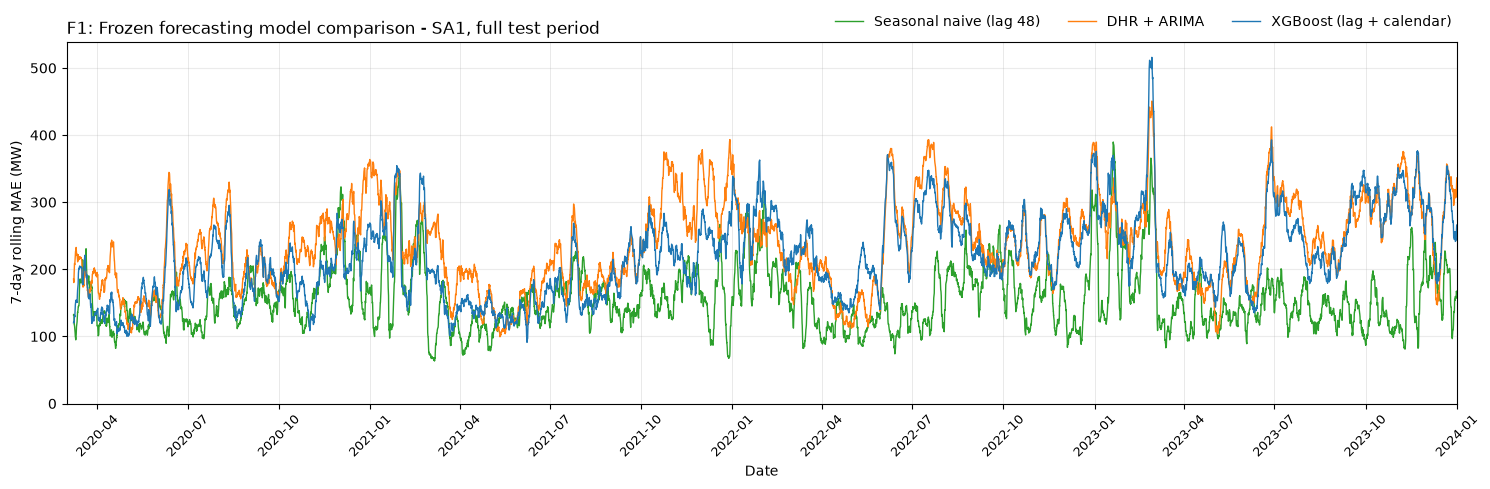

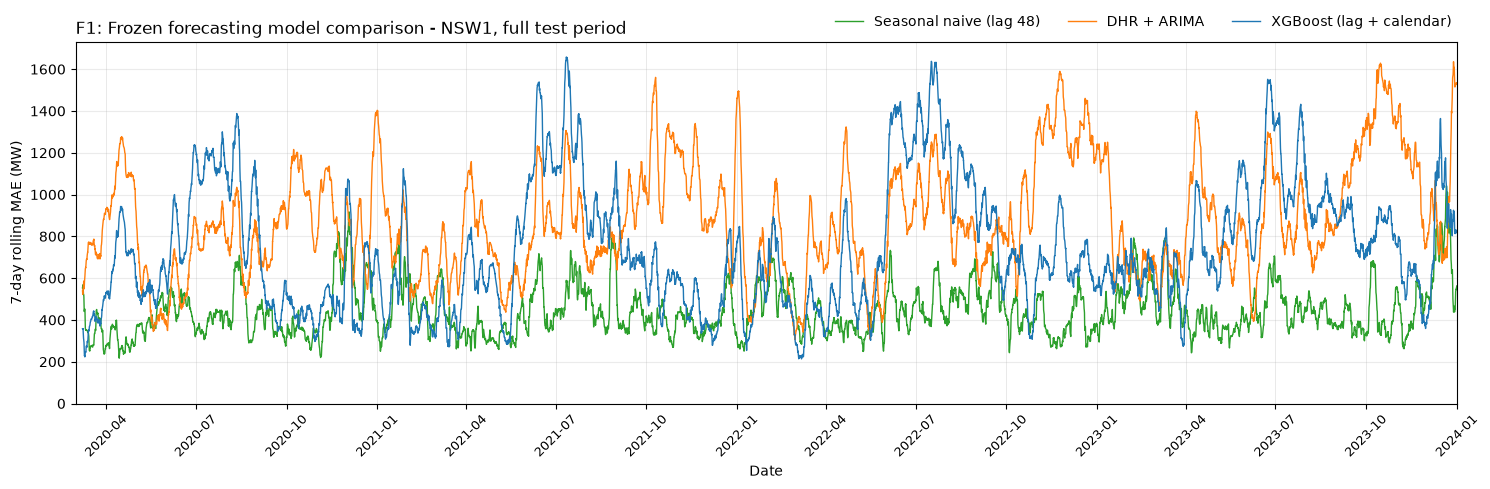

In [4]:
PERIOD_START = pd.Timestamp("2020-03-01")
PERIOD_END = pd.Timestamp("2024-01-01")


def plot_full_period(region: str) -> None:
    fig, ax = plt.subplots(figsize=(15, 5))

    for key, spec in MODELS.items():
        series = curves[region][key]
        ax.plot(series.index, series.values, label=spec["label"],
                color=spec["color"], linewidth=1.0)

    ax.set_title(
        f"F1: Frozen forecasting model comparison - {region}, full test period",
        loc="left",
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("7-day rolling MAE (MW)")
    ax.set_xlim(PERIOD_START, PERIOD_END)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)
    ax.grid(alpha=0.25)
    ax.grid(which="major", axis="x", alpha=0.4, linewidth=0.5)
    ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.02),
              ncol=len(MODELS), frameon=False, borderaxespad=0.0)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"f1_comparison_{region}_full.png",
                dpi=130, bbox_inches="tight")
    plt.show()


for region in REGIONS:
    plot_full_period(region)


**What the full-period panels show:** the ranking is stable for both regions — **seasonal naive lowest, XGBoost in the middle, DHR+ARIMA highest** — and all three share the same seasonal wobble and the same big excursions, so those spikes are genuine demand anomalies rather than model artefacts.

The important difference is the *trend*. Seasonal naive is essentially **flat** across the four years (SA1 ≈154→157 MW, NSW1 ≈423→467 MW year-average) — because it re-anchors on the observation one day earlier, it barely degrades. Both extrapolating models drift **upward** year over year: DHR+ARIMA +20% for SA1 (216→259) and +15% for NSW1 (815→938); XGBoost +40% for SA1 (183→255) and +19% for NSW1 (683→816). XGBoost starts as the better extrapolator in 2020 but degrades fastest and has nearly caught DHR+ARIMA by 2023.

So the widening gap between the flat naive line and the two rising extrapolation lines is the concept-drift signal: a frozen model that never re-anchors loses ground as the demand process moves away from its 2018–2019 training window.

## 4. Per-year comparison — one figure per region per year

Same three lines, but split by calendar year so month-to-month changes are legible. Documented events from `events.csv` are overlaid in red (NEM-wide events on both regions; region-specific events only on their region).

In [5]:
# Documented AEMO/AER events, used to annotate the per-year panels below.
EVENTS_PATH = next(
    path
    for path in (Path("events.csv"), Path("notebooks/exploration/events.csv"))
    if path.exists()
)
events = pd.read_csv(EVENTS_PATH)
events["start_date"] = pd.to_datetime(events["start_date"], format="%Y-%m-%d", errors="coerce")
events["end_date"] = pd.to_datetime(events["end_date"], format="%Y-%m-%d", errors="coerce")

unparseable = events[events["start_date"].isna() | events["end_date"].isna()]
if not unparseable.empty:
    print("WARNING: skipping events with unparseable dates:")
    display(unparseable[["event_id", "event_name", "start_date", "end_date"]])
    events = events.dropna(subset=["start_date", "end_date"]).reset_index(drop=True)

print(f"Loaded {len(events)} events from {EVENTS_PATH}")

EVENT_COLOR = "tab:red"
EVENT_LINE_KW = dict(color=EVENT_COLOR, linestyle="--", linewidth=1.0, alpha=0.7)
EVENT_SPAN_KW = dict(color=EVENT_COLOR, alpha=0.07, linewidth=0)
_LABEL_LEVELS = (0.96, 0.87, 0.78, 0.69, 0.60, 0.51)
_LABEL_GAP = pd.Timedelta(days=2)


def annotate_events(ax: plt.Axes, region: str, year: int) -> None:
    year_start = pd.Timestamp(year=year, month=1, day=1)
    year_end = pd.Timestamp(year=year + 1, month=1, day=1)

    in_scope = events[
        events["region"].isin([region, "NEM"])
        & (events["start_date"] < year_end)
        & (events["end_date"] >= year_start)
    ].sort_values("start_date")

    for i, (_, event) in enumerate(in_scope.iterrows()):
        is_period = event["end_date"] != event["start_date"]
        level = _LABEL_LEVELS[i % len(_LABEL_LEVELS)]
        label = event["event_name"]

        if is_period:
            for edge in (event["start_date"], event["end_date"]):
                if year_start <= edge < year_end:
                    ax.axvline(edge, **EVENT_LINE_KW)
            span_start = max(event["start_date"], year_start)
            span_end = min(event["end_date"], year_end)
            ax.axvspan(span_start, span_end, **EVENT_SPAN_KW)
            ax.text(span_start + (span_end - span_start) / 2, level, label,
                    transform=ax.get_xaxis_transform(), ha="center", va="top",
                    fontsize=6.5, color=EVENT_COLOR)
        else:
            edge = event["start_date"]
            ax.axvline(edge, **EVENT_LINE_KW)
            near_right = edge > year_end - pd.Timedelta(days=45)
            ax.text(edge - _LABEL_GAP if near_right else edge + _LABEL_GAP, level, label,
                    transform=ax.get_xaxis_transform(),
                    ha="right" if near_right else "left", va="top",
                    fontsize=6.5, color=EVENT_COLOR)


Loaded 24 events from events.csv


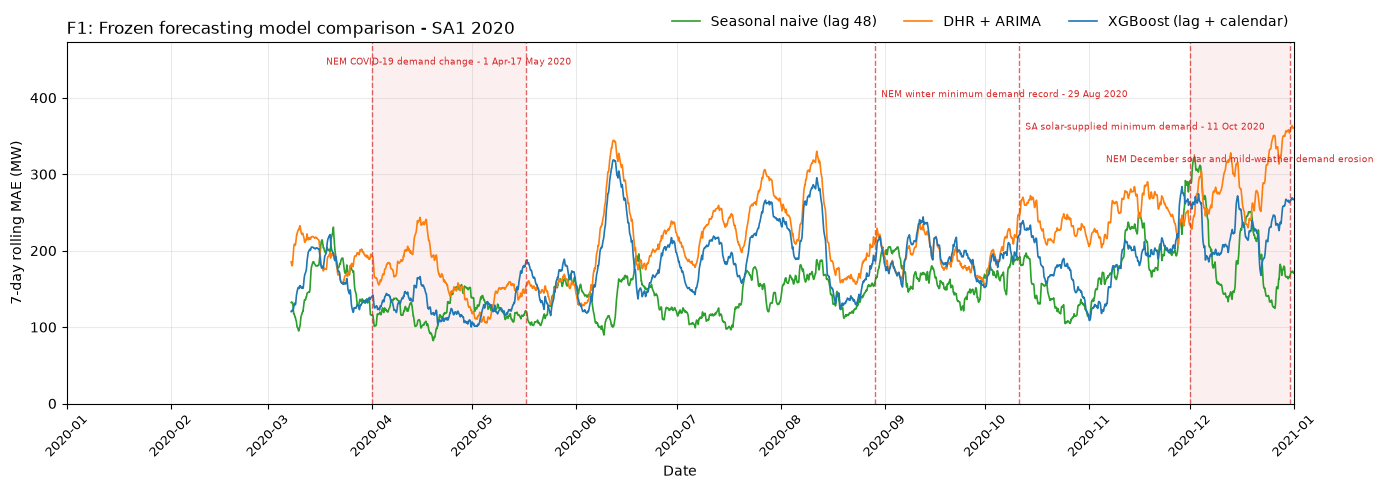

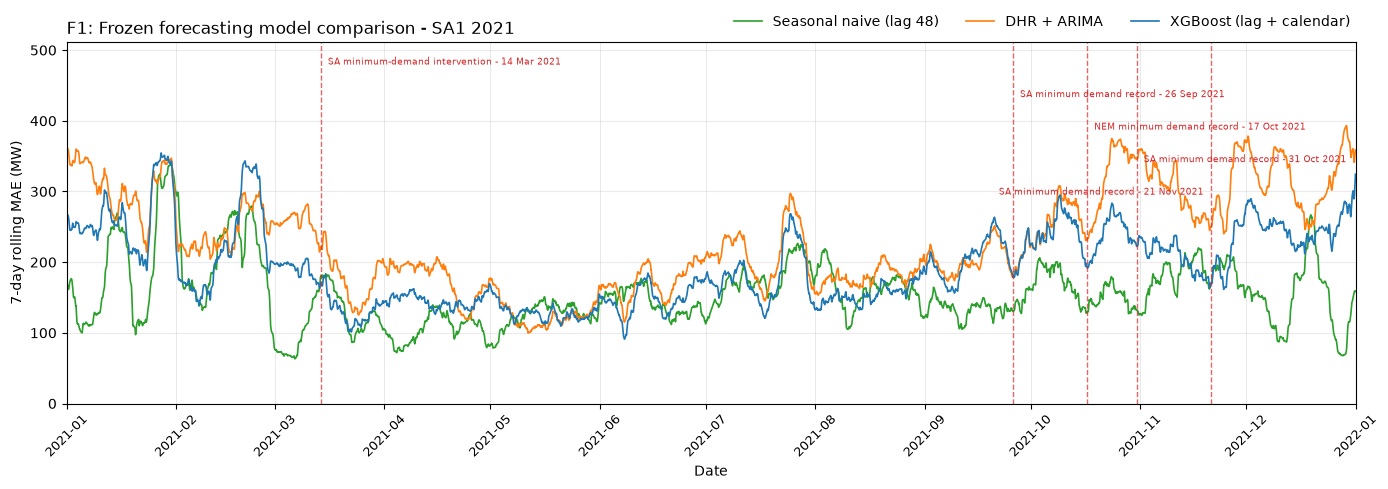

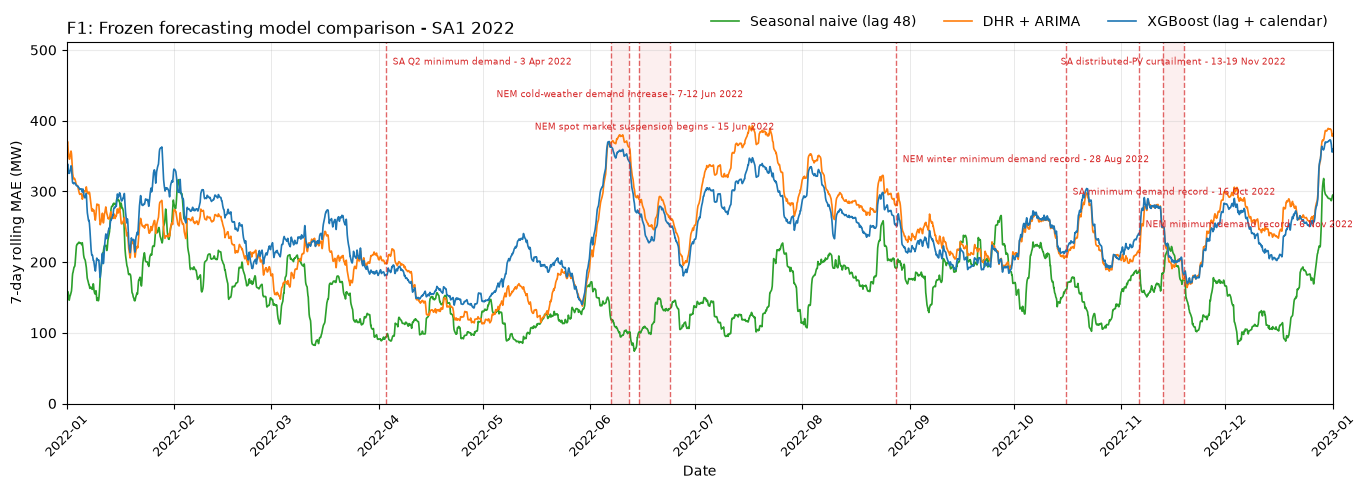

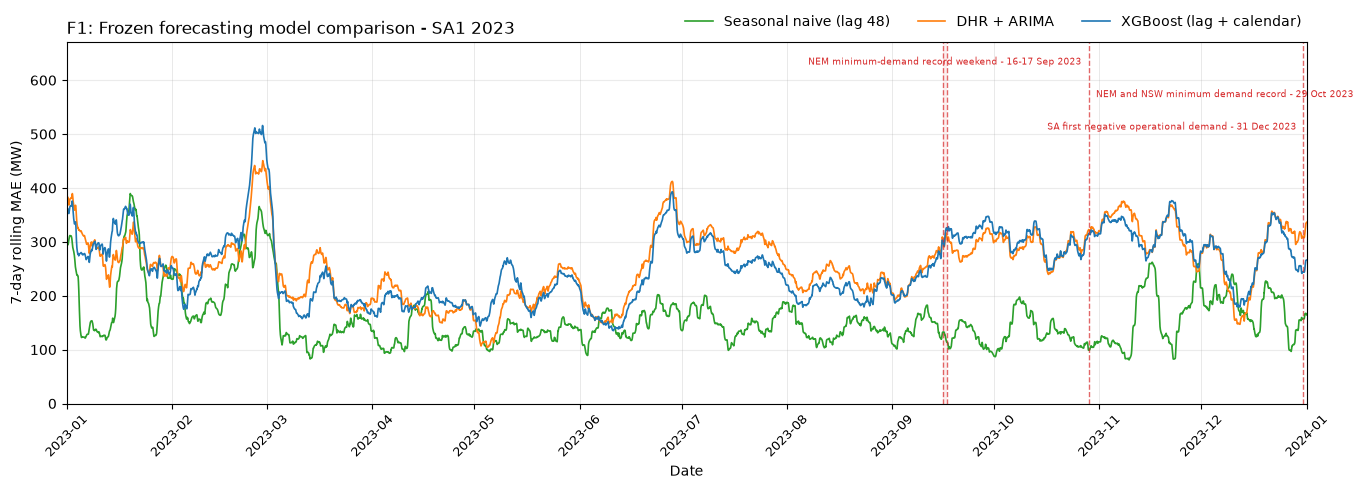

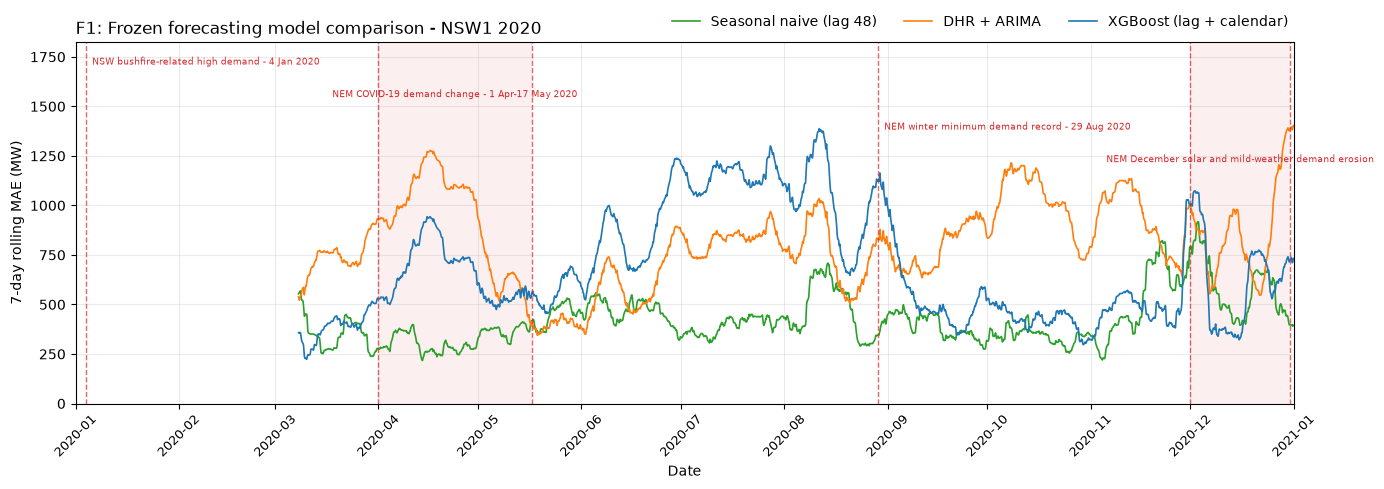

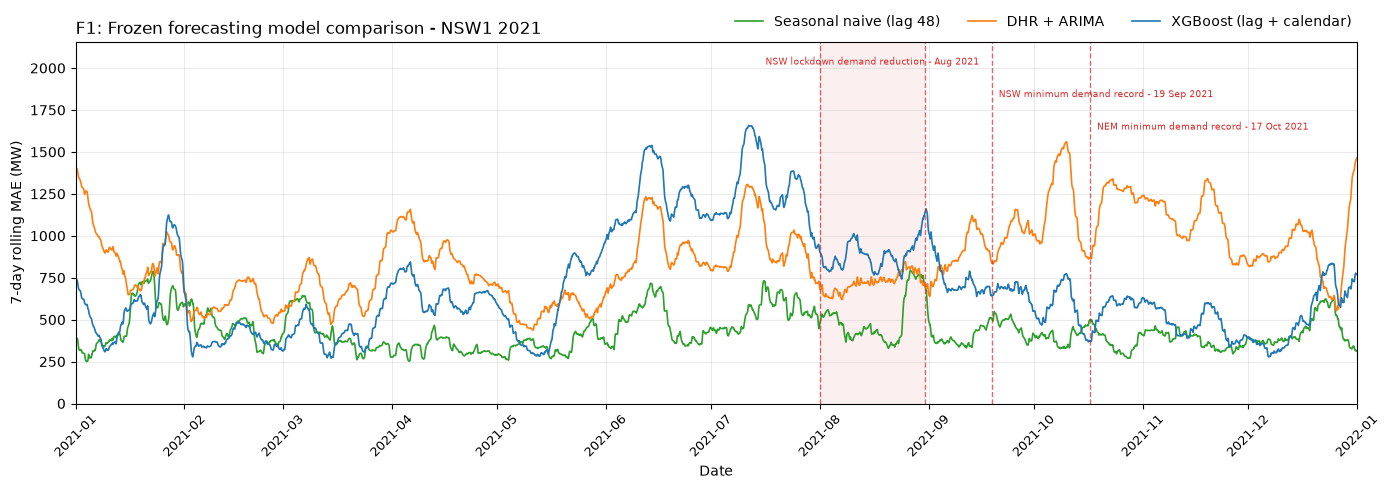

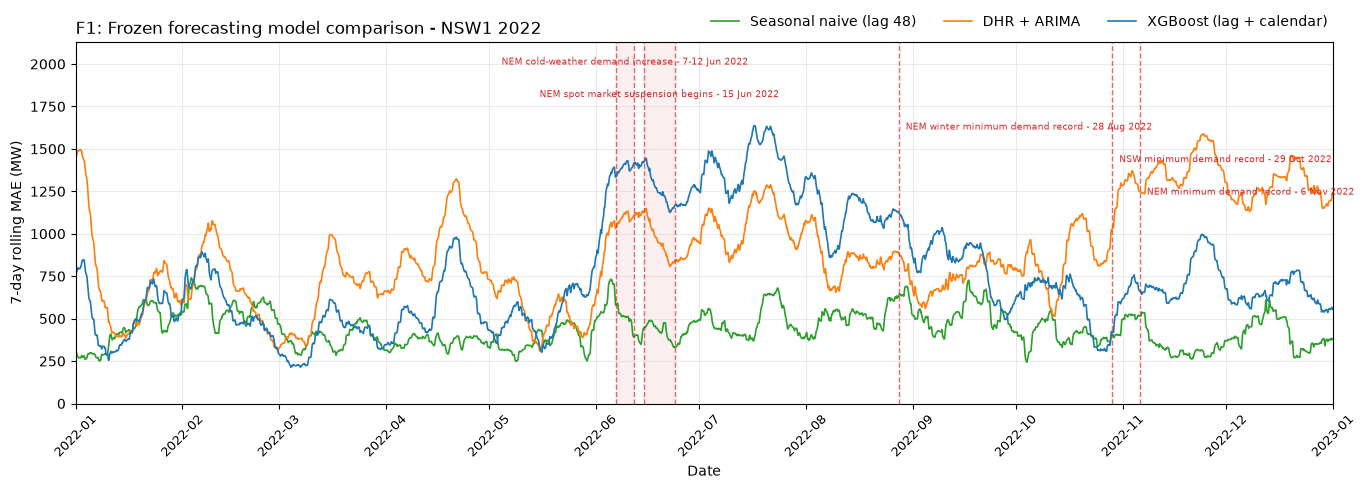

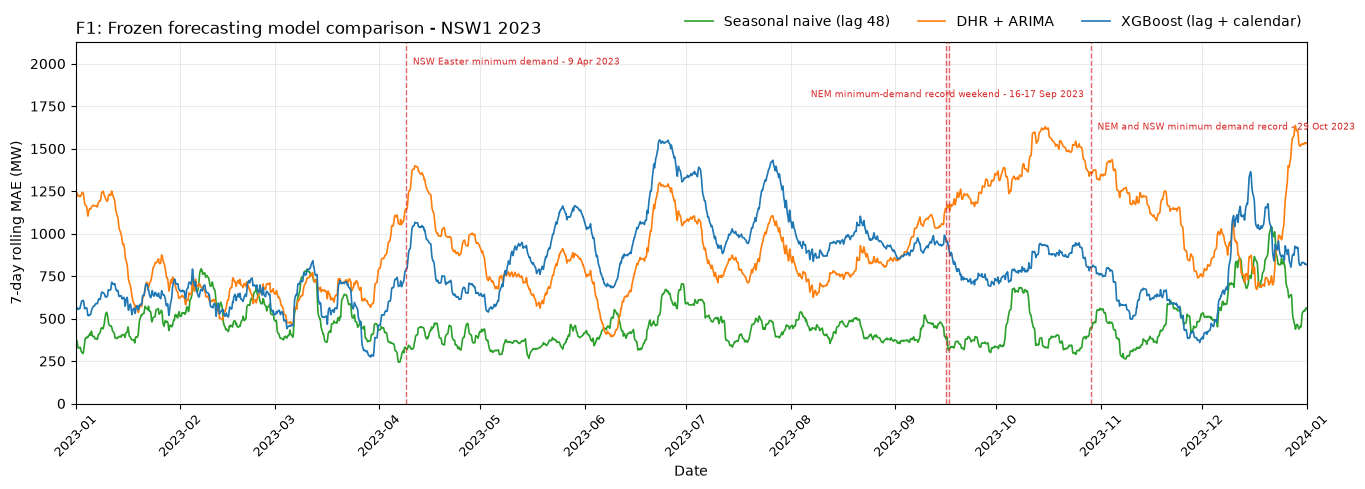

In [6]:
def format_month_axis(ax: plt.Axes, year: int) -> None:
    ax.set_xlim(pd.Timestamp(year=year, month=1, day=1),
                pd.Timestamp(year=year + 1, month=1, day=1))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)
    ax.grid(alpha=0.25)
    ax.grid(which="major", axis="x", alpha=0.4, linewidth=0.5)


def plot_region_year(region: str, year: int) -> None:
    fig, ax = plt.subplots(figsize=(14, 5))

    year_max = 0.0
    for key, spec in MODELS.items():
        series = curves[region][key]
        year_series = series[series.index.year == year]
        ax.plot(year_series.index, year_series.values, label=spec["label"],
                color=spec["color"], linewidth=1.2)
        if year_series.notna().any():
            year_max = max(year_max, year_series.max())

    if year_max > 0:
        ax.set_ylim(0, year_max * 1.30)

    annotate_events(ax, region, year)

    ax.set_title(
        f"F1: Frozen forecasting model comparison - {region} {year}", loc="left"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("7-day rolling MAE (MW)")
    format_month_axis(ax, year)
    ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.02),
              ncol=len(MODELS), frameon=False, borderaxespad=0.0)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"f1_comparison_{region}_{year}.png",
                dpi=130, bbox_inches="tight")
    plt.show()


for region in REGIONS:
    for year in TEST_YEARS:
        plot_region_year(region, year)


**What the per-year panels show:** in 2020 the three lines sit close together (within ~60 MW for SA1, ~150 MW for NSW1); by 2023 the two extrapolating models have pulled well clear of seasonal naive for months at a time — most starkly on NSW1, where DHR+ARIMA runs 1,200–1,600 MW through winter/spring 2023 while naive stays near 400–700 MW.

The two regions diverge in *opposite* seasons: SA1's spread is widest in summer (Nov–Feb), when both extrapolators overshoot the demand swing; NSW1's spread is widest in **winter** (Jun–Oct), when both — DHR+ARIMA especially — badly under-track cold-weather heating demand. XGBoost tracks the shape better than DHR+ARIMA within each year but is noisier.

Against the documented events: the rooftop-solar minimum-demand records don't align with the largest MAE excursions — those are broad seasonal mismatches, not single-day shocks. The one event that does coincide with a lasting change is the **June 2022 NEM market-suspension window**, at the start of a sustained step-up in both extrapolators' NSW1 error.

**Suggested caption:** Seven-day rolling mean absolute error (336 half-hourly forecasts) of three frozen forecasting baselines over the test stream, per region — a full-period panel and one panel per calendar year. Seasonal naive re-anchors on the observation one day earlier; DHR+ARIMA and XGBoost extrapolate from the training window. Documented events are contextual reference points, not ground-truth changepoints.